# Fall 2024 Data Science Project

**Name(s):**

---

## Contributions

> For each member, list which sections they worked on and summarize contributions in 1-2 sentences. Be specific!

---

### Member 1 — Neil Gomes

- **A: Project Idea** — Brought up the idea of analzying crime data in montgomery county 
- **B: Dataset Curation and Preprocessing** — Converted the `Start_Date_Time` column 
from raw string format to a datetime object and extracted the hour as a new feature 
to enable time-based analysis.
- **C: Data Exploration and Summary Statistics** — I analyzed how crime frequency varies throughout the day by extracting the hour from the Start_Date_Time column and computing the proportion of crimes occurring at each hour. Performed a hypthosize testing on if crimes occur uniformly across all hours. 
- **D: ML Algorithm Design/Development** — 
- **E: ML Algorithm Training and Test Data Analysis** — 
- **F: Visualization, Result Analysis, Conclusion** — 
- **G: Final Tutorial Report Creation** — Created the introductory markdown cells 
- **H: Additional** — 

---

### Member 2 — Thomas Chuss

- **A: Project Idea** — 
- **B: Dataset Curation and Preprocessing** — 
- **C: Data Exploration and Summary Statistics** — 
- **D: ML Algorithm Design/Development** — 
- **E: ML Algorithm Training and Test Data Analysis** — 
- **F: Visualization, Result Analysis, Conclusion** — 
- **G: Final Tutorial Report Creation** — 
- **H: Additional** — 

---

### Member 3 — Benjamin Nathan

- **A: Project Idea** — 
- **B: Dataset Curation and Preprocessing** — 
- **C: Data Exploration and Summary Statistics** — 
- **D: ML Algorithm Design/Development** — 
- **E: ML Algorithm Training and Test Data Analysis** — 
- **F: Visualization, Result Analysis, Conclusion** — 
- **G: Final Tutorial Report Creation** — 
- **H: Additional** — 

---

### Member 4 — Jazmine Yambo

- **A: Project Idea** — 
- **B: Dataset Curation and Preprocessing** — 
- **C: Data Exploration and Summary Statistics** — 
- **D: ML Algorithm Design/Development** — 
- **E: ML Algorithm Training and Test Data Analysis** — 
- **F: Visualization, Result Analysis, Conclusion** — 
- **G: Final Tutorial Report Creation** — 
- **H: Additional** — 

The data that we decided to clean, analyze, and interpret is a listing of criminal incidents in Montgomery County, MD over the last 10 years. The idea behind choosing this dataset was to find trends in the classification of these incidents, whether of not multiple victims were involved, and where these crimes happened.

Ideally, a model should be able to tell us something about the type of crime committed if given the location, time, and number of victims, more specifically whether or not the crime had multiple victims.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# **Data Preprocessing**

In [3]:
df = pd.read_csv('Crime_20260326.csv')

/var/folders/5h/njyblbyd3j12mx86__9v7v840000gn/T/ipykernel_89865/162940994.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Crime_20260326.csv')


First, we can see that columns 1 and 20 have mixed types. So, let us fix that.

In [4]:
col_1 = df.iloc[:,1].apply(type).value_counts()
col_20 = df.iloc[:,20].apply(type).value_counts()

print("Unique types in column 1:", col_1)
print("\nUnique types in column 20:", col_20)

Unique types in column 1: Offence Code
<class 'int'>    393216
<class 'str'>     97156
Name: count, dtype: int64

Unique types in column 20: PRA
<class 'str'>      490363
<class 'float'>         9
Name: count, dtype: int64


Let's make all of column 1 a numeric type! Column 20 will be dropped, so it's no big deal.

In [5]:
# Get rows that are str
str_rows = df.iloc[:,1].apply(lambda elem: isinstance(elem, str))
str_rows_df = df[str_rows].copy()

# Use Int64 in case of NaN values
str_rows_df.iloc[:,1] = str_rows_df.iloc[:,1].apply(lambda elem: pd.to_numeric(elem, errors= 'coerce')).astype('Int64')
col_1 = str_rows_df.iloc[:,1].apply(type).value_counts()
num_nan = str_rows_df.iloc[:,1].isna().sum()
print("Unique types in column 1:", col_1)

Unique types in column 1: Offence Code
<class 'int'>                            97151
<class 'pandas._libs.missing.NAType'>        5
Name: count, dtype: int64


So, there are 5 rows that ended up as NA type. Let's take a look at what these values are.

In [6]:
# Get the original values of the NA types
NA_types = df[pd.to_numeric(df.iloc[:, 1], errors='coerce').isna()]
NA_types.iloc[:,1]

40402     FTAS
362526    NSUP
365141    FTAS
465171    FTAS
480032    FTAS
Name: Offence Code, dtype: object

To keep everything numeric, let us change these two non-numeric values to numeric values. All offence codes are four digits, so we will differentiate these values by making them three digits.

In [7]:
# Change the FTAS and NSUP codes to numeric codes
df.loc[df['Offence Code']=='FTAS', 'Offence Code'] = 111
df.loc[df['Offence Code']=='NSUP', 'Offence Code'] = 222

# Update original df
df.iloc[:,1] = df.iloc[:,1].apply(lambda elem: pd.to_numeric(elem, errors= 'coerce')).astype('Int64')

# Make sure there are no NA types after conversion
col_1 = df.iloc[:,1].apply(type).value_counts()
num_nan = df.iloc[:,1].isna().sum()
print("Unique types in column 1:", col_1)

Unique types in column 1: Offence Code
<class 'int'>    490372
Name: count, dtype: int64


In [8]:
df.head(3)

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Start_Date_Time,End_Date_Time,NIBRS Code,Victims,Crime Name1,Crime Name2,...,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Latitude,Longitude,Police District Number,Location
0,201573262,9199,260018703,05/01/2026 04:05:27 AM,05/01/2026 04:05:00 AM,NaN,90Z,1,Crime Against Society,All Other Offenses,...,380,3900.0,NaN,MADISON PARK,NaN,LA,39.08055,-76.9311,3D,"(39.0806, -76.9311)"
1,201573259,9061,260018694,05/01/2026 01:01:48 AM,05/01/2026 12:45:00 AM,NaN,90Z,1,Crime Against Society,All Other Offenses,...,266,1600.0,NaN,ROCKVILLE,NaN,PIK,39.06289,-77.1248,1D,"(39.0629, -77.1248)"
2,201573259,5707,260018694,05/01/2026 01:01:48 AM,05/01/2026 12:45:00 AM,NaN,90J,1,Crime Against Society,Trespass of Real Property,...,266,1600.0,NaN,ROCKVILLE,NaN,PIK,39.06289,-77.1248,1D,"(39.0629, -77.1248)"


Let's take a look at all of the columns now!

In [9]:
df.columns

Index(['Incident ID', 'Offence Code', 'CR Number', 'Dispatch Date / Time',
       'Start_Date_Time', 'End_Date_Time', 'NIBRS Code', 'Victims',
       'Crime Name1', 'Crime Name2', 'Crime Name3', 'Police District Name',
       'Block Address', 'City', 'State', 'Zip Code', 'Agency', 'Place',
       'Sector', 'Beat', 'PRA', 'Address Number', 'Street Prefix',
       'Street Name', 'Street Suffix', 'Street Type', 'Latitude', 'Longitude',
       'Police District Number', 'Location'],
      dtype='object')

This is, on its own, way too many columns. Let's simplify this to only the attributes we actually need for our analysis. Given that all of this crime data is in Montgomery County, macro location information such as latitude and longitude may not seem particularly important to us, but these statistics are very useful as a numerical (i.e. not categorical) way for our model to interpret physical location. As a result, we will keep this data around for later. A location column that isn't useful to us, however, is state. State is a rather amusingly useless statistic in this particular data set, as all of the crimes in this dataset took place in Maryland.

This data set fragments an address into four parts: Number, Prefix, Street, Suffix, and Type. (i.e. - 200, "N", "WASHINGTON", NaN, "ST" refers to the address 200 N Washington Street.)  We're unlikely to perform specific measurements on exact street name, but we would like to keep the names around for human analysis, as it may be interesting.

In [10]:
df = df.drop(['State', 'PRA'], axis=1)

In [11]:
df['Full Street Name'] = (
    df['Street Prefix'].fillna('') + " " +
    df['Street Name'].fillna('') + " " +
    df['Street Suffix'].fillna('') + " " +
    df['Street Type'].fillna('')
)

Next, let's check for duplicate entries!

In [12]:
dupes = df[df.duplicated()]
print("Number of duplicated rows:", dupes.shape[0])

Number of duplicated rows: 0


There are none. Hurrah!

In [13]:
df['Victims'].describe()
df['Victims'].value_counts().sort_index()

print("Descriptive Statistics for Victims:")
print(df['Victims'].describe())

print("\nCrime Counts by Number of Victims:")
print(df['Victims'].value_counts().sort_index())

Descriptive Statistics for Victims:
count    490372.000000
mean          1.021796
std           0.184570
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          22.000000
Name: Victims, dtype: float64

Crime Counts by Number of Victims:
Victims
1     481641
2       7424
3        893
4        279
5         85
6         22
7         21
8          4
9          2
22         1
Name: count, dtype: int64


# **Data Exploration #1: Distribution of Crime by Victim Count**

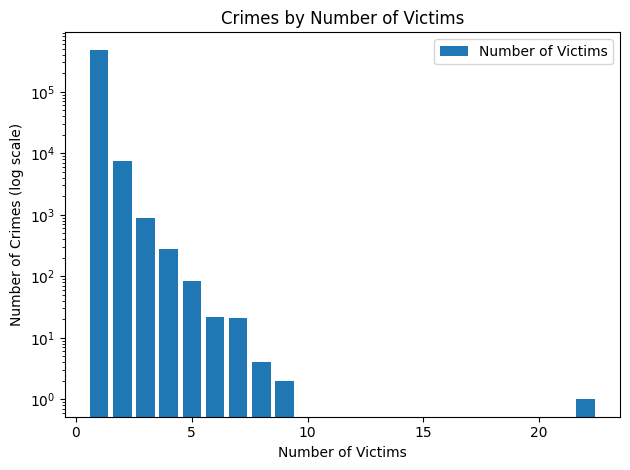

In [14]:
# Get counts sorted by number of victims
counts = df['Victims'].value_counts().sort_index()

# Create the plot
plt.figure()
plt.bar(counts.index, counts.values, label= 'Number of Victims')

# Labels and title
plt.xlabel("Number of Victims")
plt.ylabel("Number of Crimes (log scale)")
plt.title("Crimes by Number of Victims")

# Make it look pretty
plt.yscale('log')
plt.tight_layout()
plt.legend()

plt.show()

Here we come to an interesting conclusion using descriptive statistics and counting the number of crimes with each quantity of victims. We can see that the vast majority of crimes victimize one person (98.2%). Most of the remainder victimize 2 people, with very few victimizing 3 or more. Importantly observe the log scale on the graph - we use it to make the higher counts visible.

Notice the one outlier with 22 victims. We looked into this crime, which allegedly happened at the Waterford Tower Apartments in Fairland on July 23rd, 2016 at 4:30 PM, and were surprised to find no such incident. The closest we found was a street riot that occurred that night at 9:45 PM, but there's another Simple Assault charge in our data at 9:40 PM, so this is not likely to be our elusive 22 victim crime. It's possible that this is simply a typo? We shall make a mental note of this.

# **Data Exploration #2: Analysis of Crime Types**

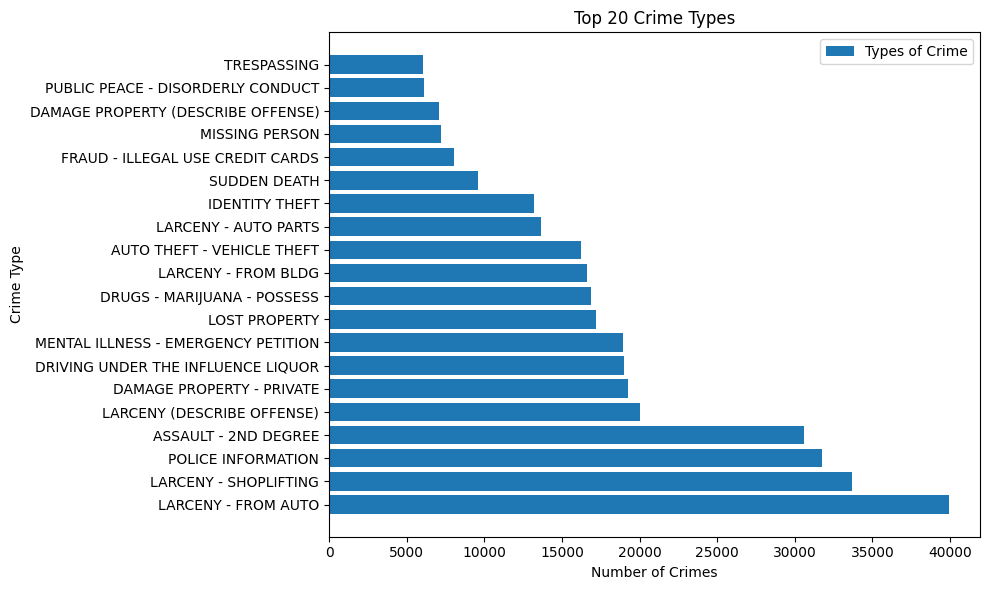

In [15]:
counts = df['Crime Name3'].fillna('Unknown').value_counts()

# Limit to top categories so it's readable
top_n = 20
top_counts = counts[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(top_counts.index, top_counts.values, label= 'Types of Crime')

plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.title("Top 20 Crime Types")

plt.legend()
plt.tight_layout()
plt.show()

Here, we can see that the top three crimes committed in Maryland are Auto Theft, Shoplifting, and Police Information. The value "Police Information" is quite ambiguous. So, let's look at the data and see what is considered "Police Information"!

In [16]:
# get the exact number of rows that contain police information
pol_info_rows = df[df['Crime Name3'] == 'POLICE INFORMATION']
pol_info_sum = pol_info_rows.shape[0]
print("Rows with 'POLICE INFORMATION' as Crime Name3:", pol_info_sum)

# get more clarity about what is considered police information
crime_1_and_2 = df.loc[df['Crime Name3'] == 'POLICE INFORMATION',
 ['Crime Name1', 'Crime Name2']].apply(lambda name: name.value_counts())

print("\nAll values from Crime Name1 and Crime Name2 where Crime Name3 is 'POLICE INFORMATION':\n\n",crime_1_and_2)

Rows with 'POLICE INFORMATION' as Crime Name3: 31771

All values from Crime Name1 and Crime Name2 where Crime Name3 is 'POLICE INFORMATION':

                        Crime Name1  Crime Name2
All Other Offenses             NaN      31771.0
Crime Against Society      31771.0          NaN


As you can see, every instance of "POLICE INFORMATION" has the same descriptors for Crime Name1 and Crime Name2: "Crime Against Society" and "All Other Offenses". So, they are types of crimes that fall into a much more general category.

# **Data Exploration #3: Using Hypothesis Testing to analyze whether different cities have different rates of multi-victim crimes**

H₀: City and multi-victim status are independent

H₁: Different cities have different rates of multi-victim crimes

alpha = 0.01

In [20]:
df['multi_victim'] = df['Victims'] > 1

top_cities = df['City'].value_counts().head(5).index
subset = df[df['City'].isin(top_cities)]

import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(subset['City'], subset['multi_victim'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 288.7266209972664
p-value: 2.925941684569359e-61


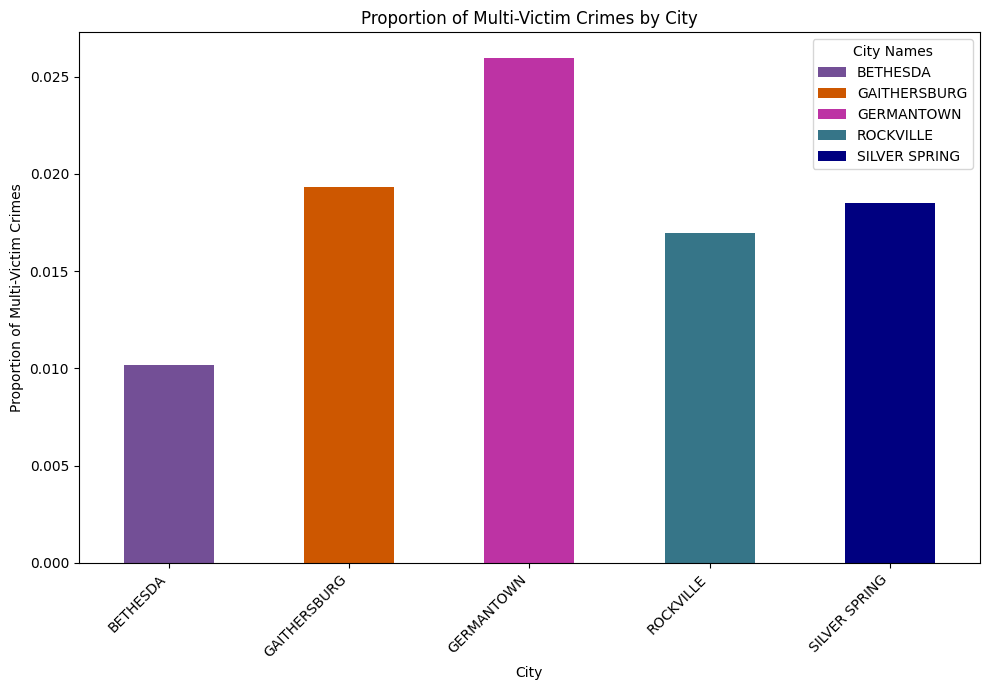

In [21]:
# Convert to proportions (row-wise)
table_prop = table.div(table.sum(axis=1), axis=0)

# Colors for the graph
colors_for_graph = ['#734f96','#cd5700','#bd33a4','#367588','#000080']

# Plot ONLY multi-victim (True)
plt.figure(figsize=(10, 7))
the_bars = table_prop[True].plot(kind='bar', color= colors_for_graph)

plt.xlabel("City")
plt.ylabel("Proportion of Multi-Victim Crimes")
plt.title("Proportion of Multi-Victim Crimes by City")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Make the legend
pat = the_bars.patches
plt.legend(handles= pat, labels= table_prop[True].index.to_list(), title= 'City Names')
plt.show()

We reject the null hypothesis and conclude that there is a statistically significant relationship between cities and multi-victim crime rates. As the p-value (7E-61) is far below alpha, we can confidently reject the null hypothesis. This is reflected in the graph above, where Germantown has the highest multi-victim rate, at over twice that of Bethesda, which has the lowest.

# **Data Exploration #4: Crime Frequency by Time of Day** 

One key dimension of our data exploration is understanding **when** crimes occur throughout the day. 
By extracting the hour from the `Start_Date_Time` column, we can examine whether certain hours 
are associated with higher crime frequency in Montgomery County.

We plot the proportion of crimes per hour (0–23) to normalize across the dataset and identify 
any clear temporal patterns — for example, whether crime peaks late at night or during commute hours.

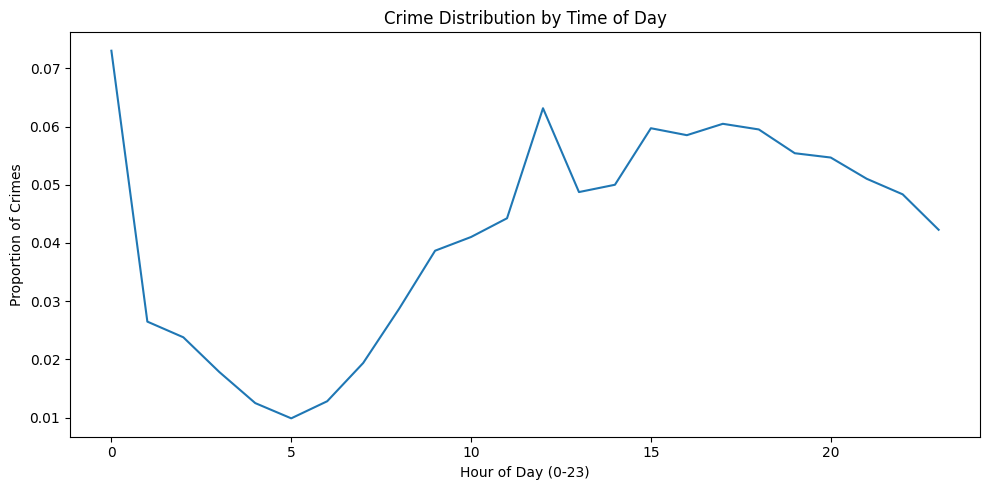

In [22]:
#Crime Frequency by Time of Day

#to datetime
df['Start_Date_Time'] = pd.to_datetime(df['Start_Date_Time'], errors='coerce')

# extract hour
df['hour'] = df['Start_Date_Time'].dt.hour

#count crimes per hour
hour_counts = df['hour'].value_counts().sort_index()

#convert to proportions
hour_prop = hour_counts / hour_counts.sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hour_prop.index, hour_prop.values)

plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Proportion of Crimes")
plt.title("Crime Distribution by Time of Day")

plt.tight_layout()
plt.show()